In [1]:
#Motivated from https://github.com/PatWalters/practicalcheminformatics/blob/master/_notebooks/2021-07-05-replace-rgroups.ipynb
#Added step for computing the Bemis-Murcko scaffold
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 36.2 MB/s eta 0:00:00


In [5]:
!pip install xmltodict

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd drive/MyDrive

/content/drive/MyDrive


In [6]:
import xmltodict
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import ReplaceCore, GetMolFrags, ReplaceSubstructs, CombineMols
from itertools import product
import numpy as np
import pandas as pd

In [10]:
def smi2cansmi(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atm in mol.GetAtoms():
            atm.SetIsotope(0)
        return Chem.MolToSmiles(mol)
    else:
        return None

In [7]:
def generate_replacement_dictionary(replacement_xml_file):
    ifs = open(replacement_xml_file)
    xml = ifs.read()
    d = xmltodict.parse(xml)

    replacement_dict = defaultdict()
    for k in d['R_replacements']['center']:
        fl = k['first_layer']
        if type(fl) is not list:
            fl = [fl]
        first_layer = [a['@SMILES'] for a in fl]
        sl = [ x for x in [a.get('second_layer') for a in fl] if x]
        second_layer = []
        for row in sl:
            if type(row) is not list:
                row = [row]
            for r in row:
                second_layer.append(r['@SMILES'])
        replacement_dict[smi2cansmi(k['@SMILES'])] = [first_layer, second_layer]
    return replacement_dict

In [12]:
def generate_replacement_dictionary(replacement_xml_file):
    ifs = open(replacement_xml_file)
    xml = ifs.read()
    d = xmltodict.parse(xml)

    replacement_dict = defaultdict()
    for k in d['R_replacements']['center']:
        fl = k['first_layer']
        if type(fl) is not list:
            fl = [fl]
        first_layer = [a['@SMILES'] for a in fl]
        sl = [ x for x in [a.get('second_layer') for a in fl] if x]
        second_layer = []
        for row in sl:
            if type(row) is not list:
                row = [row]
            for r in row:
                second_layer.append(r['@SMILES'])
        replacement_dict[smi2cansmi(k['@SMILES'])] = [first_layer, second_layer]
    return replacement_dict

In [13]:
replacement_dict["*O"]

[['*OC', '*N', '*CO', '*OC(C)=O', '*C(=O)NO'],
 ['*Cl', '*OCC', '*NC', '*NC(C)=O', '*C(C)O', '*C(C)(C)O', '*CC(=O)NO']]

In [14]:
use_second_layer = True

In [15]:
def get_replacements(smi, replacement_dict):
    cansmi = smi2cansmi(smi)
    return replacement_dict.get(cansmi, [[cansmi], [cansmi]])

In [16]:
get_replacements("*CC",replacement_dict)

[['*C(C)C', '*CCC', '*C1CC1', '*CCCC', '*C=C'],
 ['*C1CCCCC1',
  '*CC(C)C',
  '*CCCCC',
  '*C1CCC1',
  '*C1CCCO1',
  '*CCCCCC',
  '*CCC(C)C']]

In [39]:
#Input smiles
smiles_target = "C(OCC(CN(CC)CC)(C)C)(=O)C1=CC=C(C=C1)N"

In [40]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

mol = Chem.MolFromSmiles(smiles_target)

# Get the Murcko scaffold
murcko = MurckoScaffold.GetScaffoldForMol(mol)
core_smarts = Chem.MolToSmiles(murcko)

print("Murcko Scaffold:", core_smarts)

Murcko Scaffold: c1ccccc1


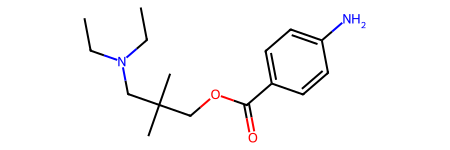

In [41]:
mol_target = Chem.MolFromSmiles(smiles_target)
mol_target

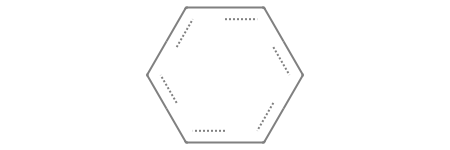

In [42]:
mol_core = Chem.MolFromSmarts(core_smarts)
mol_core

In [43]:
mol_target.HasSubstructMatch(mol_core)

True

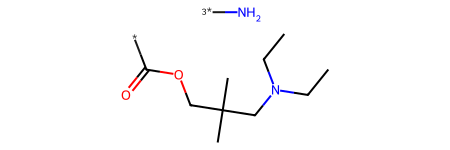

In [44]:
sidechain_mol = ReplaceCore(mol_target,mol_core,labelByIndex=True)
sidechain_mol

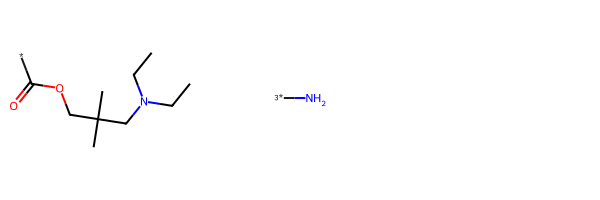

In [45]:
sidechain_frag_list = GetMolFrags(sidechain_mol,asMols=True)
Chem.Draw.MolsToGridImage(sidechain_frag_list)

In [46]:
def get_connect_idx(mol):
    return max([x.GetIsotope() for x in mol.GetAtoms()])

In [47]:
attach_idx = [get_connect_idx(x) for x in sidechain_frag_list]
attach_idx

[0, 3]

In [48]:
sidechain_smiles = [Chem.MolToSmiles(x) for x in sidechain_frag_list]
sidechain_smiles

['*C(=O)OCC(C)(C)CN(CC)CC', '[3*]N']

In [49]:
replacement_smiles = [get_replacements(x,replacement_dict) for x in sidechain_smiles]
replacement_smiles

[[['*C(=O)OCC(C)(C)CN(CC)CC'], ['*C(=O)OCC(C)(C)CN(CC)CC']],
 [['*O', '*NC', '*NC(C)=O', '*CN', '*NCc1ccccc1'],
  ['*OC',
   '*CO',
   '*NCC',
   '*NC1CC1',
   '*NC(=O)CC',
   '*NC(=O)C1CC1',
   '*CCN',
   '*C1CCCN1',
   '*NCCc1ccccc1',
   '*NC1CCCCC1']]]

In [50]:
if use_second_layer:
    tmp_smiles = [a+b for a,b in replacement_smiles]
else:
    tmp_smiles = [x[0] for x in replacement_smiles]
replacement_smiles = tmp_smiles

In [51]:
clean_sidechain_smiles = [smi2cansmi(x) for x in sidechain_smiles]
tmp_list = []
for i,j in zip(clean_sidechain_smiles,replacement_smiles):
    tmp_list.append([i]+j)
replacement_smiles = tmp_list

In [52]:
def prep_sidechain(smi):
    mol = Chem.MolFromSmiles(smi)
    rw_mol = Chem.RWMol(mol)
    remove_idx = -1
    for atm in rw_mol.GetAtoms():
        if atm.GetAtomicNum() == 0:
            remove_idx = atm.GetIdx()
            for nbr in atm.GetNeighbors():
                nbr.SetAtomMapNum(1)
    rw_mol.RemoveAtom(remove_idx)
    Chem.SanitizeMol(rw_mol)
    return rw_mol

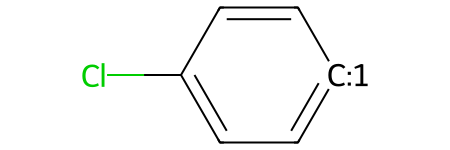

In [53]:
prep_sidechain('*c1ccc(Cl)cc1')

In [54]:
def make_analogs(core,attach_pts,sidechains):
    prod_list = []
    for c in product(*sidechains):
        sidechain_mol_list = [prep_sidechain(x) for x in c]
        mol = Chem.RWMol(core)
        for start_atm,m in zip(attach_pts,sidechain_mol_list):
            mol = Chem.RWMol(CombineMols(mol,m))
            end_atm = -1
            for atm in mol.GetAtoms():
                if atm.GetAtomMapNum() == 1:
                    end_atm = atm.GetIdx()
            mol.AddBond(start_atm, end_atm, order=Chem.rdchem.BondType.SINGLE)
            for atm in mol.GetAtoms():
                atm.SetAtomMapNum(0)
        prod_list.append(Chem.MolToSmiles(mol))
    return prod_list

In [55]:
analog_list = make_analogs(mol_core,attach_idx,replacement_smiles)
len(analog_list)

48

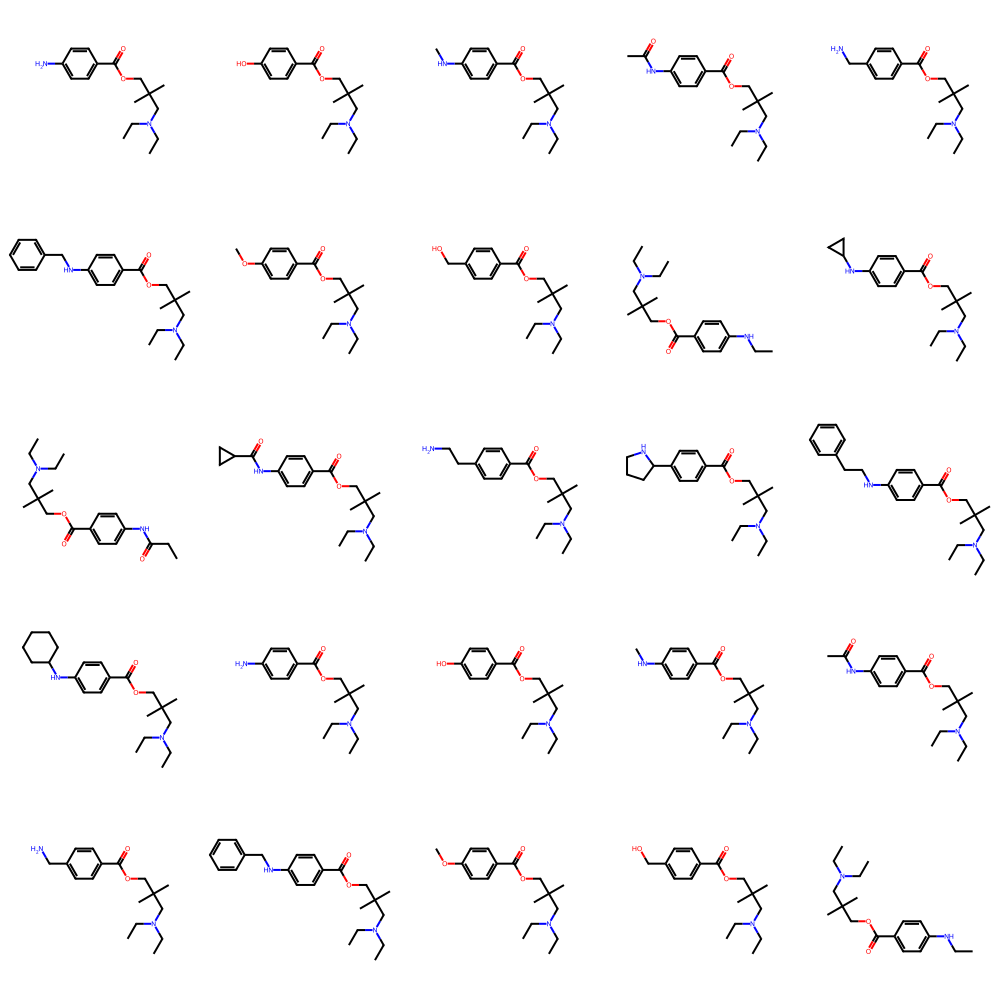

In [56]:
# Align the molecules
mol_list = [Chem.MolFromSmiles(x) for x in analog_list]
AllChem.Compute2DCoords(mol_core)
[AllChem.GenerateDepictionMatching2DStructure(x,mol_core) for x in mol_list]
# Display the grid
Chem.Draw.MolsToGridImage(mol_list[:25],molsPerRow=5)